 Building a CNN for MNIST Handwritten Digit Classification

## Introduction

Welcome! In this assignment, you will build a Convolutional Neural Network (CNN) to classify handwritten digits from the famous MNIST dataset. This dataset is a classic in the field of computer vision and provides a great starting point for understanding image classification with deep learning.

This notebook is structured to guide you step-by-step through the process. You will load the data, preprocess it, define a CNN model, train it, and evaluate its performance.  Throughout the assignment, you will have opportunities to experiment and deepen your understanding of the concepts.

Remember to:

*   **Read all instructions carefully.**
*   **Execute the code cells in order.**
*   **Fill in the missing code sections marked as "Students: Fill in the blanks".**
*   **Answer the reflection questions in the designated Markdown cell.**
*   **Experiment and explore!**  Change parameters, layers, and observe the effects.

Let's get started and build our MNIST digit classifier!

## Section 1: Setting Up - Imports

Before we dive into building our CNN, we need to import the necessary libraries.  These libraries provide pre-built tools and functions that will make our work much easier.

**Instructions:**

1.  **Carefully review the code cell below.** It imports libraries from TensorFlow and Keras, which are powerful frameworks for building and training neural networks.
2.  **Execute the code cell by selecting it and pressing [Shift + Enter] (or the "Run" button).**
3.  **Ensure there are no error messages after running the cell.** If you encounter errors, double-check that you have TensorFlow and Keras installed in your environment.

In [ ]:
# Cell 1: Imports

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Visual import explanation

print("═" * 74)
print("                  NEURAL NETWORK RESEARCH LAB")
print("                      Import Crew: Online")
print("═" * 74)

print(f"""
  ┌────────────────────────────────────────────────────────────────────┐
  │ TensorFlow Engine                                                  │
  │                                                                    │
  │ import tensorflow as tf                                            │
  │                                                                    │
  │ Role: The computational engine that performs tensor math,          │
  │ manages hardware acceleration, and powers deep-learning tasks.    │
  │ Status: ONLINE — TensorFlow {tf.__version__}                       │
  └────────────────────────────────────────────────────────────────────┘
""")

print("""
  ┌────────────────────────────────────────────────────────────────────┐
  │ Keras Model Architect                                              │
  │                                                                    │
  │ from tensorflow import keras                                       │
  │                                                                    │
  │ Role: TensorFlow's high-level interface for designing, compiling, │
  │ training, and evaluating neural-network models.                    │
  │ Status: READY — model construction tools unlocked                  │
  └────────────────────────────────────────────────────────────────────┘
""")

print("""
  ┌────────────────────────────────────────────────────────────────────┐
  │ Layers Construction Team                                           │
  │                                                                    │
  │ from tensorflow.keras import layers                                │
  │                                                                    │
  │ Role: Supplies neural-network building blocks such as Dense,      │
  │ Conv2D, MaxPooling2D, Flatten, and Dropout layers.                 │
  │ Status: READY — architecture components available                  │
  └────────────────────────────────────────────────────────────────────┘
""")

print("""
  ┌────────────────────────────────────────────────────────────────────┐
  │ MNIST Digital Archive                                              │
  │                                                                    │
  │ from tensorflow.keras.datasets import mnist                        │
  │                                                                    │
  │ Role: Provides convenient access to handwritten-digit images       │
  │ used to train and evaluate an image-classification model.         │
  │ Status: READY — digit archive connection established               │
  └────────────────────────────────────────────────────────────────────┘
""")

print("""
  ┌────────────────────────────────────────────────────────────────────┐
  │ Label Translator                                                   │
  │                                                                    │
  │ from tensorflow.keras.utils import to_categorical                  │
  │                                                                    │
  │ Role: Converts a label such as 3 into a one-hot vector:           │
  │                                                                    │
  │             3  ->  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]                  │
  │                                                                    │
  │ Status: READY — labels can be prepared for classification          │
  └────────────────────────────────────────────────────────────────────┘
""")

print("═" * 74)
print("IMPORT MISSION COMPLETE")
print("The research lab is equipped to load digits, build a CNN,")
print("train it, and translate predictions into digit classes.")
print("═" * 74)

══════════════════════════════════════════════════════════════════════════
                  NEURAL NETWORK RESEARCH LAB
                      Import Crew: Online
══════════════════════════════════════════════════════════════════════════

  ┌────────────────────────────────────────────────────────────────────┐
  │ TensorFlow Engine                                                  │
  │                                                                    │
  │ import tensorflow as tf                                            │
  │                                                                    │
  │ Role: The computational engine that performs tensor math,          │
  │ manages hardware acceleration, and powers deep-learning tasks.    │
  │ Status: ONLINE — TensorFlow 2.20.0                       │
  └────────────────────────────────────────────────────────────────────┘


  ┌────────────────────────────────────────────────────────────────────┐
  │ Keras Model Architect               

In [ ]:
# Imports and visual status displays

import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("Checking for the MNIST dataset...")

# Default Keras cache location
cache_dir = os.path.join(os.path.expanduser("~"), ".keras", "datasets")
os.makedirs(cache_dir, exist_ok=True)

mnist_path = os.path.join(cache_dir, "mnist.npz")

if os.path.exists(mnist_path):
    size_mb = os.path.getsize(mnist_path) / (1024 * 1024)
    print(f"   MNIST dataset already downloaded.")
    print(f"   File: {mnist_path}")
    print(f"   Size: {size_mb:.2f} MB")
else:
    print("⬇  Downloading MNIST dataset...")
    print("   A progress bar should appear below.\n")

    # keras.utils.get_file displays a download progress bar
    mnist_path = keras.utils.get_file(
        fname="mnist.npz",
        origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz",
        cache_dir=os.path.expanduser("~"),
        cache_subdir=".keras/datasets"
    )

    size_mb = os.path.getsize(mnist_path) / (1024 * 1024)
    print(f"\n Download complete.")
    print(f"   Saved to: {mnist_path}")
    print(f"   Size: {size_mb:.2f} MB")

print("\nLoading MNIST into memory...")

# Load the locally downloaded file
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(" MNIST loaded successfully!")
print(f"Training images: {x_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test images:     {x_test.shape}")
print(f"Test labels:     {y_test.shape}")

import os
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist

def pause(seconds=0.7):
    time.sleep(seconds)

def divider():
    print("═" * 68)

def status(icon, title, message=""):
    print(f"\n{icon}  {title}")
    if message:
        print(f"   {message}")

# ─────────────────────────────────────────────────────────────────────────────
# 1. Opening scene: TensorFlow starts
# ─────────────────────────────────────────────────────────────────────────────

divider()
print("             M N I S T   D I G I T   A R C H I V E")
print("                  Neural Network Loading Bay")
divider()

status("⚙️", "TensorFlow engine online", f"Version {tf.__version__}")
pause()

# ─────────────────────────────────────────────────────────────────────────────
# 2. Inspect Keras cache / vault
# ─────────────────────────────────────────────────────────────────────────────

cache_dir = os.path.join(os.path.expanduser("~"), ".keras", "datasets")
mnist_path = os.path.join(cache_dir, "mnist.npz")

status("🔎", "Searching the Keras data vault...")
pause()

if os.path.exists(mnist_path):
    size_mb = os.path.getsize(mnist_path) / (1024 * 1024)

    print(r"""
                 ┌──────────────────────────────┐
                 │        DATA VAULT FOUND       │
                 │          ┌──────────┐         │
                 │          │ MNIST    │         │
                 │          │  ARCHIVE │         │
                 │          └──────────┘         │
                 └──────────────────────────────┘
    """)

    status("✅", "Archive recovered from local storage")
    print(f"   Location: {mnist_path}")
    print(f"   Weight:   {size_mb:.2f} MB")

else:
    status("⬇️", "MNIST archive is missing — requesting delivery...")
    print("\n   Satellite link: [░░░░░░░░░░░░░░░░░░░░] 0%")
    pause()

    keras.utils.get_file(
        fname="mnist.npz",
        origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz",
        cache_dir=os.path.expanduser("~"),
        cache_subdir=".keras/datasets"
    )

    print("\n   Satellite link: [████████████████████] 100%")
    status("Archive delivered and secured in the data vault")

# ─────────────────────────────────────────────────────────────────────────────
# 3. Load dataset
# ─────────────────────────────────────────────────────────────────────────────

status("📂", "Opening the MNIST archive...")
pause()

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(r"""
              ╔══════════════════════════════════════╗
              ║       HANDWRITING RESEARCH LAB       ║
              ║                                      ║
              ║     0   1   2   3   4   5   6   7      ║
              ║     8   9   →  Neural Network        ║
              ╚══════════════════════════════════════╝
""")

pause()

# ─────────────────────────────────────────────────────────────────────────────
# 4. Dataset inventory
# ─────────────────────────────────────────────────────────────────────────────

divider()
print("                       DATASET INVENTORY")
divider()

print(f"""
  ┌─────────────────────┬──────────────┬─────────────────────────┐
  │ Collection          │ Image Count  │ Image Format            │
  ├─────────────────────┼──────────────┼─────────────────────────┤
  │ Training workshop   │ {x_train.shape[0]:>10,}   │ {x_train.shape[1]} × {x_train.shape[2]} grayscale pixels │
  │ Final examination   │ {x_test.shape[0]:>10,}   │ {x_test.shape[1]} × {x_test.shape[2]} grayscale pixels │
  └─────────────────────┴──────────────┴─────────────────────────┘
""")

print("  Label classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9")
print(f"  Training labels: {y_train.shape[0]:,}")
print(f"  Test labels:     {y_test.shape[0]:,}")

divider()
print("   MISSION COMPLETE: 70,000 handwritten digits are ready for training.")
print("   Next stage: normalize pixels and build the neural network.")
divider()


TensorFlow version: 2.20.0
Checking for the MNIST dataset...
⬇  Downloading MNIST dataset...
   A progress bar should appear below.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 Download complete.
   Saved to: /root/.keras/datasets/mnist.npz
   Size: 10.96 MB

Loading MNIST into memory...
 MNIST loaded successfully!
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images:     (10000, 28, 28)
Test labels:     (10000,)
════════════════════════════════════════════════════════════════════
             M N I S T   D I G I T   A R C H I V E
                  Neural Network Loading Bay
════════════════════════════════════════════════════════════════════

⚙️  TensorFlow engine online
   Version 2.20.0

🔎  Searching the Keras data vault...

                 ┌──────────────────────────────┐
                 │        DATA VAULT FOUND       │
                 │          ┌──────────┐         │
                 │          │ MNIST    │         │
                 │          │  A

**Explanation of Imports:**

*   **`tensorflow as tf` and `keras`:** TensorFlow is the main deep learning framework, and Keras is its high-level API that simplifies building and training models. We import TensorFlow as `tf` and Keras directly for easy access to their functionalities.
*   **`from tensorflow.keras import layers`:**  This imports the `layers` module from Keras, which provides various layers for building neural networks (like convolutional layers, dense layers, etc.).
*   **`from tensorflow.keras.datasets import mnist`:**  This imports the MNIST dataset directly from Keras datasets.  This is very convenient for loading and using the MNIST data.
*   **`from tensorflow.keras.utils import to_categorical`:**  This imports the `to_categorical` function, which we will use to perform one-hot encoding of our labels.

## Section 2: Data Loading and Preprocessing

In this section, we will load the MNIST dataset and prepare it for training our CNN model.  Preprocessing steps are crucial to ensure our data is in the right format for the model to learn effectively.

**Instructions:**

1.  **Read through the code in the cell below.**  Understand how it loads the MNIST dataset and what preprocessing steps are applied.
2.  **Execute the code cell.**
3.  **Examine the comments in the code** to understand each preprocessing step in detail.

════════════════════════════════════════════════════════════════════════

                 CNN DATA PREPARATION CENTER
              Image Conversion & Feature Preparation

════════════════════════════════════════════════════════════════════════

┌────────────────────────────────────────────────────────────────────┐
│ STAGE 01 — RAW IMAGE COLLECTION                                    │
├────────────────────────────────────────────────────────────────────┤
│ Loading handwritten images before neural processing                │
└────────────────────────────────────────────────────────────────────┘


 Incoming Training Data:

 Images  : (60000, 28, 28)
 Labels  : (60000,)

 Image Type:
     Height : 28 pixels
     Width  : 28 pixels
     Color  : Grayscale (1 channel)

 Pixel Information:

     Dark Pixel  = 0
     Bright Pixel = 255



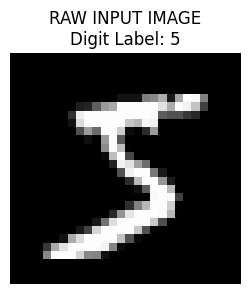


┌────────────────────────────────────────────────────────────────────┐
│ STAGE 02 — PIXEL NORMALIZATION                                     │
├────────────────────────────────────────────────────────────────────┤
│ Converting human image values into neural network values           │
└────────────────────────────────────────────────────────────────────┘


Before:

    Pixel Range:

        0 ───────────────────── 255


Transformation:

        pixel / 255


After:

        0.0 ─────────────────── 1.0


Purpose:

The CNN learns more efficiently when inputs
are placed into a consistent numerical range.


Normalized Training Range:

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0



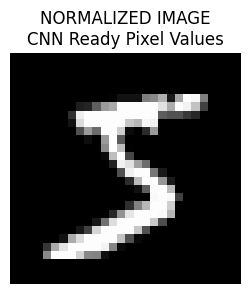


┌────────────────────────────────────────────────────────────────────┐
│ STAGE 03 — IMAGE DIMENSION CONVERSION                              │
├────────────────────────────────────────────────────────────────────┤
│ Adding channel information required by Conv2D layers               │
└────────────────────────────────────────────────────────────────────┘


Before CNN formatting:

    (Images, Height, Width)

    (60000, 28, 28)


After CNN formatting:

    (Images, Height, Width, Channels)

    (60000, 28, 28, 1)


Channel Explanation:

    1 = grayscale image channel

New Training Shape:
(60000, 28, 28, 1)

┌────────────────────────────────────────────────────────────────────┐
│ STAGE 04 — LABEL TRANSLATION                                       │
├────────────────────────────────────────────────────────────────────┤
│ Converting digit answers into neural network format                │
└────────────────────────────────────────────────────────────────────┘


Original Human Label:

     

In [ ]:
# Cell 2: Data Loading and Preprocessing
# Neural Network Data Preparation Pipeline

import matplotlib.pyplot as plt
import numpy as np

def divider():
    print("═" * 72)

def stage(title, message):
    print(f"""
┌────────────────────────────────────────────────────────────────────┐
│ {title:<66} │
├────────────────────────────────────────────────────────────────────┤
│ {message:<66} │
└────────────────────────────────────────────────────────────────────┘
""")

divider()
print("""
                 CNN DATA PREPARATION CENTER
              Image Conversion & Feature Preparation
""")
divider()


# ---------------------------------------------------------
# Stage 1: Raw Dataset
# ---------------------------------------------------------

stage(
    "STAGE 01 — RAW IMAGE COLLECTION",
    "Loading handwritten images before neural processing"
)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"""
 Incoming Training Data:

 Images  : {x_train.shape}
 Labels  : {y_train.shape}

 Image Type:
     Height : 28 pixels
     Width  : 28 pixels
     Color  : Grayscale (1 channel)

 Pixel Information:

     Dark Pixel  = 0
     Bright Pixel = 255
""")


# Display original image

sample = 0

plt.figure(figsize=(3,3))
plt.imshow(x_train[sample], cmap="gray")
plt.title(f"RAW INPUT IMAGE\nDigit Label: {y_train[sample]}")
plt.axis("off")
plt.show()



# ---------------------------------------------------------
# Stage 2: Normalization
# ---------------------------------------------------------

stage(
    "STAGE 02 — PIXEL NORMALIZATION",
    "Converting human image values into neural network values"
)


print("""
Before:

    Pixel Range:

        0 ───────────────────── 255


Transformation:

        pixel / 255


After:

        0.0 ─────────────────── 1.0


Purpose:

The CNN learns more efficiently when inputs
are placed into a consistent numerical range.
""")


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


print(f"""
Normalized Training Range:

Minimum Pixel Value: {x_train.min()}
Maximum Pixel Value: {x_train.max()}
""")


plt.figure(figsize=(3,3))
plt.imshow(x_train[sample], cmap="gray")
plt.title("NORMALIZED IMAGE\nCNN Ready Pixel Values")
plt.axis("off")
plt.show()



# ---------------------------------------------------------
# Stage 3: CNN Shape Conversion
# ---------------------------------------------------------

stage(
    "STAGE 03 — IMAGE DIMENSION CONVERSION",
    "Adding channel information required by Conv2D layers"
)


print("""
Before CNN formatting:

    (Images, Height, Width)

    (60000, 28, 28)


After CNN formatting:

    (Images, Height, Width, Channels)

    (60000, 28, 28, 1)


Channel Explanation:

    1 = grayscale image channel
""")


x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)


print("New Training Shape:")
print(x_train.shape)



# ---------------------------------------------------------
# Stage 4: Label Encoding
# ---------------------------------------------------------

stage(
    "STAGE 04 — LABEL TRANSLATION",
    "Converting digit answers into neural network format"
)


print("""
Original Human Label:

        7


One-Hot Neural Representation:

        [0,0,0,0,0,0,0,1,0,0]


Why?

The CNN compares probability across
all possible digit classes.
""")


num_classes = 10

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


print("Example Encoded Label:")
print(y_train[sample])


# ---------------------------------------------------------
# Completion
# ---------------------------------------------------------

divider()

print("""
                 DATA PREPARATION COMPLETE

      IMAGE  →  NORMALIZED PIXELS  →  CNN TENSOR
                         |
                         ↓
                 ONE-HOT CLASS LABEL

The dataset is now prepared for CNN training.
""")

divider()

**Explanation of Data Preprocessing:**

*   **Loading the MNIST dataset:** `mnist.load_data()` loads the MNIST dataset, which is already split into training and testing sets (`(x_train, y_train), (x_test, y_test)`). `x_train` and `x_test` contain the images (pixel data), and `y_train` and `y_test` contain the corresponding labels (digits 0-9).
*   **Normalization:** `x_train = x_train.astype("float32") / 255.0` and `x_test = x_test.astype("float32") / 255.0` normalize the pixel values.  Pixel values in images are typically in the range 0-255. Dividing by 255 scales them to the range 0-1. This normalization helps the neural network train faster and more effectively.
*   **Adding Channel Dimension:** `x_train = x_train.reshape(-1, 28, 28, 1)` and `x_test = x_test.reshape(-1, 28, 28, 1)` reshape the data to add a channel dimension.  Even though MNIST images are grayscale (single channel), CNNs in Keras expect input data to have a channel dimension.  We reshape from `(number_of_images, 28, 28)` to `(number_of_images, 28, 28, 1)`. The `-1` in `reshape` means "infer the dimension based on the size of the array."
*   **One-Hot Encoding:** `y_train = to_categorical(y_train, num_classes)` and `y_test = to_categorical(y_test, num_classes)` perform one-hot encoding on the labels.  Instead of representing the digit '3' as a single number, one-hot encoding converts it into a vector `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`, where the 4th position (index 3) is 'hot' (value 1), and all other positions are 'cold' (value 0). This is a standard way to represent categorical labels for neural networks in multi-class classification problems. `num_classes = 10` specifies that we have 10 classes (digits 0-9).

## Section 3: Model Definition - Building the CNN

Now we will define the architecture of our Convolutional Neural Network (CNN).  You will be building a sequential model using Keras layers.

**Instructions:**

1.  **Carefully examine the code in the cell below.** Notice the structure of the `keras.Sequential` model.
2.  **Fill in the missing parts** marked with `# Students: Fill in the blanks` to complete the model definition.
3.  **Experiment!** You are encouraged to try different configurations for the layers, such as changing the number of filters in the convolutional layers, or adding more layers.

In [ ]:
# Cell 3: CNN Model Definition
# Neural Network Architecture Construction Lab

from tensorflow import keras
from tensorflow.keras import layers

def divider():
    print("═" * 76)

def module(title, description):
    print(f"""
┌────────────────────────────────────────────────────────────────────────────┐
│ {title:<74} │
├────────────────────────────────────────────────────────────────────────────┤
│ {description:<74} │
└────────────────────────────────────────────────────────────────────────────┘
""")


divider()

print("""
              CNN ARCHITECTURE CONSTRUCTION LAB

              Building the feature detection system
              that will learn handwritten digits
""")

divider()



# ---------------------------------------------------------
# Input Layer
# ---------------------------------------------------------

module(
    "MODULE 01 — IMAGE INPUT SYSTEM",
    "Receiving prepared MNIST image tensors"
)

print("""
Incoming Data:

    Image Shape:

        Height       Width      Channel

          28    x     28    x      1


The CNN receives grayscale images
prepared in the previous stage.
""")



# ---------------------------------------------------------
# Build CNN Architecture
# ---------------------------------------------------------

module(
    "MODULE 02 — FEATURE EXTRACTION ENGINE",
    "Creating convolution and pooling layers"
)


model = keras.Sequential(
    [

        # Input
        keras.Input(shape=(28,28,1)),


        # First convolution
        layers.Conv2D(
            32,
            kernel_size=(3,3),
            activation="relu"
        ),


        # First pooling
        layers.MaxPooling2D(
            pool_size=(2,2)
        ),


        # Second convolution
        layers.Conv2D(
            64,
            kernel_size=(3,3),
            activation="relu"
        ),


        # Second pooling
        layers.MaxPooling2D(
            pool_size=(2,2)
        ),


        # Convert feature maps into vector
        layers.Flatten(),


        # Reduce overfitting
        layers.Dropout(
            0.5
        ),


        # Classification output
        layers.Dense(
            num_classes,
            activation="softmax"
        )
    ]
)



# ---------------------------------------------------------
# Explain Architecture
# ---------------------------------------------------------

divider()

print("""
                    CNN PROCESSING PIPELINE


        ┌──────────────────────────┐
        │ MNIST IMAGE INPUT        │
        │ 28 x 28 x 1              │
        └────────────┬─────────────┘
                     │
                     ▼

        ┌──────────────────────────┐
        │ Conv2D                   │
        │ 32 Filters               │
        │ Learns edges & shapes    │
        └────────────┬─────────────┘
                     │
                     ▼

        ┌──────────────────────────┐
        │ MaxPooling               │
        │ Reduces image size       │
        │ Keeps important features │
        └────────────┬─────────────┘
                     │
                     ▼

        ┌──────────────────────────┐
        │ Conv2D                   │
        │ 64 Filters               │
        │ Learns complex patterns  │
        └────────────┬─────────────┘
                     │
                     ▼

        ┌──────────────────────────┐
        │ MaxPooling               │
        │ Compresses features      │
        └────────────┬─────────────┘
                     │
                     ▼

        ┌──────────────────────────┐
        │ Flatten                  │
        │ Converts features into   │
        │ classification vector    │
        └────────────┬─────────────┘
                     │
                     ▼

        ┌──────────────────────────┐
        │ Dropout 50%              │
        │ Prevents memorization    │
        └────────────┬─────────────┘
                     │
                     ▼

        ┌──────────────────────────┐
        │ Softmax Output           │
        │ 10 Digit Probabilities   │
        └──────────────────────────┘

""")


# ---------------------------------------------------------
# Model Summary
# ---------------------------------------------------------

divider()

print("MODEL BLUEPRINT GENERATED")
print("Displaying CNN component inventory...\n")

model.summary()

divider()

print("""
CNN ARCHITECTURE COMPLETE

The network can now:

    Receive images
          ↓
    Extract visual features
          ↓
    Reduce unnecessary information
          ↓
    Classify digits 0-9


Next Stage:
Training the CNN and adjusting its learned weights.
""")

divider()

════════════════════════════════════════════════════════════════════════════

              CNN ARCHITECTURE CONSTRUCTION LAB

              Building the feature detection system
              that will learn handwritten digits

════════════════════════════════════════════════════════════════════════════

┌────────────────────────────────────────────────────────────────────────────┐
│ MODULE 01 — IMAGE INPUT SYSTEM                                             │
├────────────────────────────────────────────────────────────────────────────┤
│ Receiving prepared MNIST image tensors                                     │
└────────────────────────────────────────────────────────────────────────────┘


Incoming Data:

    Image Shape:

        Height       Width      Channel

          28    x     28    x      1


The CNN receives grayscale images
prepared in the previous stage.


┌────────────────────────────────────────────────────────────────────────────┐
│ MODULE 02 — FEATURE EXTRACTION EN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

════════════════════════════════════════════════════════════════════════════

CNN ARCHITECTURE COMPLETE

The network can now:

    Receive images
          ↓
    Extract visual features
          ↓
    Reduce unnecessary information
          ↓
    Classify digits 0-9


Next Stage:
Training the CNN and adjusting its learned weights.

════════════════════════════════════════════════════════════════════════════


**Explanation of Layers:**

*   **`keras.Input(shape=(28, 28, 1))`:** This is the input layer of our model. It specifies the shape of the input images, which are 28x28 pixels with 1 channel (grayscale).
*   **`layers.Conv2D(32, kernel_size=(3, 3), activation="relu")`:** This is a 2D Convolutional layer.
    *   `32`: This is the number of filters (also called kernels). Each filter learns to detect specific features in the input image.
    *   `kernel_size=(3, 3)`: This defines the size of the convolutional filter as 3x3 pixels.
    *   `activation="relu"`:  ReLU (Rectified Linear Unit) is the activation function. It introduces non-linearity into the model, allowing it to learn complex patterns.
*   **`layers.MaxPooling2D(pool_size=(2, 2))`:** This is a Max Pooling layer.
    *   `pool_size=(2, 2)`:  It reduces the spatial dimensions of the feature maps by taking the maximum value within each 2x2 window. This helps to reduce the number of parameters, control overfitting, and make the model more robust to small shifts and distortions in the input.
*   **`layers.Flatten()`:** This layer flattens the 2D feature maps from the convolutional and pooling layers into a 1D vector. This is necessary to connect the convolutional part of the network to the fully connected (Dense) layers.
*   **`layers.Dropout(0.5)`:** This is a Dropout layer.
    *   `0.5`: This sets the dropout rate to 50%. During training, this layer randomly sets 50% of the input units to 0 at each update. This is a regularization technique that helps to prevent overfitting.
*   **`layers.Dense(num_classes, activation="softmax")`:** This is the output Dense (fully connected) layer.
    *   `num_classes`:  This is set to 10 because we have 10 classes (digits 0-9).
    *   `activation="softmax"`: Softmax activation ensures that the output values are probabilities, and they sum up to 1 across all classes.  The output will be a vector of 10 probabilities, where each probability represents the model's confidence that the input image belongs to that specific digit class.

## Section 4: Model Compilation - Choosing Loss and Optimizer

Before we can train our model, we need to compile it.  Compilation involves choosing an optimizer, a loss function, and metrics to evaluate the model's performance.

**Instructions:**

1.  **Examine the code cell below.** You need to fill in the blanks for the `loss` and `optimizer` parameters in `model.compile()`.
2.  **Choose an appropriate loss function and optimizer** for this multi-class classification problem.
3.  **In the Markdown cell after the code, explain your choices.** Why are these choices suitable for this task?

In [ ]:
# Cell 4: Model Compilation
# CNN Learning Configuration Center

def divider():
    print("═" * 76)

def module(title, description):
    print(f"""
┌────────────────────────────────────────────────────────────────────────────┐
│ {title:<74} │
├────────────────────────────────────────────────────────────────────────────┤
│ {description:<74} │
└────────────────────────────────────────────────────────────────────────────┘
""")


divider()

print("""
              CNN LEARNING CONFIGURATION CENTER

          Preparing the model's training instructions

""")

divider()



# ---------------------------------------------------------
# Learning Strategy Explanation
# ---------------------------------------------------------

module(
    "SYSTEM 01 — ERROR MEASUREMENT",
    "Selecting the method used to calculate prediction mistakes"
)


print("""
LOSS FUNCTION SELECTED:

        categorical_crossentropy


Purpose:

The CNN predicts probabilities for 10 possible digits:

Example:

Digit Prediction:

0 → 0.01
1 → 0.02
2 → 0.03
3 → 0.90  <--- Highest confidence
4 → 0.01
...

Categorical cross-entropy compares:

    Model Prediction

          VS

    Correct Answer


The goal:

Reduce the difference between
predicted probabilities and the true label.
""")



# ---------------------------------------------------------
# Optimizer Explanation
# ---------------------------------------------------------

module(
    "SYSTEM 02 — WEIGHT ADJUSTMENT ENGINE",
    "Choosing how the CNN improves after mistakes"
)


print("""
OPTIMIZER SELECTED:

        Adam


Purpose:

Adam updates the CNN's internal weights
after each training step.

Learning cycle:

    Image
      |
      ↓
    Prediction
      |
      ↓
    Calculate Error
      |
      ↓
    Adam Adjusts Weights
      |
      ↓
    Improved Prediction


Adam is commonly used because it combines
adaptive learning rates with efficient updates.
""")



# ---------------------------------------------------------
# Metric Explanation
# ---------------------------------------------------------

module(
    "SYSTEM 03 — PERFORMANCE MONITOR",
    "Tracking how often the CNN predicts correctly"
)


print("""
METRIC SELECTED:

        accuracy


Accuracy measures:

Correct Predictions
────────────────────
Total Predictions


Example:

9500 correct predictions
out of 10000 images


Accuracy = 95%

This gives a simple measurement
of classification performance.
""")



# ---------------------------------------------------------
# Compile Model
# ---------------------------------------------------------

divider()

print("""
                 ACTIVATING TRAINING SETTINGS...

Loss Function:
    categorical_crossentropy

Optimizer:
    Adam

Metric:
    Accuracy

""")



model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)



divider()

print("""
                 MODEL CONFIGURATION COMPLETE


The CNN now knows:

✔ How to measure mistakes
✔ How to correct itself
✔ How success will be evaluated


Next Stage:

Training begins as the CNN learns
from thousands of handwritten examples.
""")

divider()

════════════════════════════════════════════════════════════════════════════

              CNN LEARNING CONFIGURATION CENTER

          Preparing the model's training instructions


════════════════════════════════════════════════════════════════════════════

┌────────────────────────────────────────────────────────────────────────────┐
│ SYSTEM 01 — ERROR MEASUREMENT                                              │
├────────────────────────────────────────────────────────────────────────────┤
│ Selecting the method used to calculate prediction mistakes                 │
└────────────────────────────────────────────────────────────────────────────┘


LOSS FUNCTION SELECTED:

        categorical_crossentropy


Purpose:

The CNN predicts probabilities for 10 possible digits:

Example:

Digit Prediction:

0 → 0.01
1 → 0.02
2 → 0.03
3 → 0.90  <--- Highest confidence
4 → 0.01
...

Categorical cross-entropy compares:

    Model Prediction

          VS

    Correct Answer


The goal:

Reduce 

**Explanation of Choices (To be filled by students in the reflection section):**

*   **Loss Function:** You need to choose a loss function that is appropriate for multi-class classification. Think about what kind of error we are trying to minimize when classifying digits into 10 categories.
*   **Optimizer:** You need to choose an optimizer that will efficiently update the model's weights to minimize the loss function.  Consider common optimizers used in deep learning.
*   **Metrics:** We are using "accuracy" as a metric to evaluate the model's performance. Accuracy is a common metric for classification tasks, representing the percentage of correctly classified images.

## Section 5: Model Training - Fitting the Model to the Data

Now it's time to train our CNN model using the training data. Training involves feeding the training data to the model and adjusting its weights to minimize the loss function.

**Instructions:**

1.  **Examine the code cell below.** You need to fill in the blanks for `batch_size` and `epochs` in `model.fit()`.
2.  **Choose appropriate values for `batch_size` and `epochs`.**
3.  **Run the code cell to start training.** Observe the training progress, especially the loss and accuracy on both the training and validation sets.
4.  **Experiment!** Change the `batch_size` and `epochs` and see how it affects the training process and the final performance.

In [ ]:
# Cell 5: Model Training
# CNN Training Simulation Center

import time


def divider():
    print("═" * 76)


def module(title, description):
    print(f"""
┌────────────────────────────────────────────────────────────────────────────┐
│ {title:<74} │
├────────────────────────────────────────────────────────────────────────────┤
│ {description:<74} │
└────────────────────────────────────────────────────────────────────────────┘
""")


divider()

print("""
              CNN TRAINING SIMULATION CENTER

          The neural network begins learning from examples

""")

divider()



# ---------------------------------------------------------
# Training Explanation
# ---------------------------------------------------------

module(
    "TRAINING SYSTEM — LEARNING LOOP",
    "Feeding examples through the CNN and improving predictions"
)


print("""
TRAINING PROCESS:


       Handwritten Image
              |
              ↓

       CNN Feature Extraction
              |
              ↓

       Digit Prediction
              |
              ↓

       Compare With Correct Answer
              |
              ↓

       Calculate Error
              |
              ↓

       Update Network Weights
              |
              ↓

       Repeat Until Improved


The CNN does not memorize images.
It learns patterns that help classify
new handwritten digits.
""")



# ---------------------------------------------------------
# Batch Size Explanation
# ---------------------------------------------------------

module(
    "PARAMETER 01 — BATCH SIZE",
    "Controlling how many images are processed at one time"
)


batch_size = 128

print(f"""
CURRENT SETTING:

    Batch Size = {batch_size}


Meaning:

The CNN processes {batch_size} images
before updating its weights.


Training Example:

60,000 images

60,000 ÷ 128

≈ 469 learning updates per epoch


Larger batches:
    + Faster processing
    - More memory usage

Smaller batches:
    + More frequent updates
    - More training noise
""")



# ---------------------------------------------------------
# Epoch Explanation
# ---------------------------------------------------------

module(
    "PARAMETER 02 — EPOCHS",
    "Determining how many times the CNN reviews the dataset"
)


epochs = 15

print(f"""
CURRENT SETTING:

    Epochs = {epochs}


One epoch means:

The CNN sees the entire training dataset once.


Current mission:

The CNN will study the handwritten digits
{epochs} complete times.
""")



# ---------------------------------------------------------
# Validation Explanation
# ---------------------------------------------------------

module(
    "PARAMETER 03 — VALIDATION CHECKPOINT",
    "Testing learning progress during training"
)


print("""
Validation Split:

    10% of training images are separated
    and used as a progress checkpoint.


Purpose:

Training Data:

    Used for learning


Validation Data:

    Used for checking if learning
    generalizes to unseen examples


This helps identify:

    ✓ Improving performance

    ⚠ Possible overfitting
""")



# ---------------------------------------------------------
# Start Training
# ---------------------------------------------------------

divider()

print("""
                 TRAINING SEQUENCE STARTING


Batch Size:
    128 images


Epoch Count:
    15 training cycles


Validation:
    10% checkpoint enabled


The CNN is now beginning to learn...
""")

divider()



history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1
)



# ---------------------------------------------------------
# Training Complete
# ---------------------------------------------------------

divider()

print("""
                 TRAINING COMPLETE


The CNN has completed its learning cycles.

The model has now adjusted:

    • Convolution filters
    • Feature detectors
    • Classification weights


Next Stage:

Evaluate performance on unseen test images.
""")

divider()

════════════════════════════════════════════════════════════════════════════

              CNN TRAINING SIMULATION CENTER

          The neural network begins learning from examples


════════════════════════════════════════════════════════════════════════════

┌────────────────────────────────────────────────────────────────────────────┐
│ TRAINING SYSTEM — LEARNING LOOP                                            │
├────────────────────────────────────────────────────────────────────────────┤
│ Feeding examples through the CNN and improving predictions                 │
└────────────────────────────────────────────────────────────────────────────┘


TRAINING PROCESS:


       Handwritten Image
              |
              ↓

       CNN Feature Extraction
              |
              ↓

       Digit Prediction
              |
              ↓

       Compare With Correct Answer
              |
              ↓

       Calculate Error
              |
              ↓

       Update Netw

**Explanation of Training Parameters:**

*   **`batch_size`:** This determines the number of training samples processed in each mini-batch during training. A larger batch size can speed up training but might require more memory. A smaller batch size can lead to more noisy updates but might generalize better.
*   **`epochs`:**  One epoch represents one complete pass through the entire training dataset.  More epochs can potentially lead to better training but also increase the risk of overfitting, where the model learns the training data too well and performs poorly on unseen data.
*   **`validation_split=0.1`:**  This reserves 10% of the training data as a validation set. During training, the model's performance is evaluated on this validation set after each epoch. This helps to monitor for overfitting and tune hyperparameters.

## Section 6: Model Evaluation - Assessing Performance on Test Data

After training, we need to evaluate our model's performance on the test dataset.  This gives us an estimate of how well the model generalizes to unseen data.

**Instructions:**

1.  **Run the code cell below.**
2.  **Observe the output.**  It will print the test loss and test accuracy.
3.  **Think about the results.** Is the test accuracy satisfactory?  How does it compare to the training and validation accuracy you observed during training?

In [10]:
# Cell 6: Model Evaluation
# CNN Evaluation Laboratory

import numpy as np


def divider():
    print("═" * 76)


def module(title, description):
    print(f"""
┌────────────────────────────────────────────────────────────────────────────┐
│ {title:<74} │
├────────────────────────────────────────────────────────────────────────────┤
│ {description:<74} │
└────────────────────────────────────────────────────────────────────────────┘
""")


divider()

print("""
              CNN EVALUATION LABORATORY

          Testing the model on unseen handwritten digits

""")

divider()



# ---------------------------------------------------------
# Evaluation Explanation
# ---------------------------------------------------------

module(
    "EVALUATION SYSTEM — GENERALIZATION TEST",
    "Measuring how well the CNN performs on new examples"
)


print("""
The CNN has completed training.

Training Data:

    Used to adjust model weights


Test Data:

    Never shown during training


Purpose:

Determine whether the CNN learned
general patterns instead of memorizing
the training images.
""")



# ---------------------------------------------------------
# Test Dataset Information
# ---------------------------------------------------------

module(
    "TEST DATABASE — MNIST EXAMINATION SET",
    "Providing unseen handwritten examples"
)


print(f"""
Test Images:

    {x_test.shape[0]:,} handwritten digits


Image Format:

    Height: {x_test.shape[1]} pixels
    Width : {x_test.shape[2]} pixels
    Channel: {x_test.shape[3]}


The CNN must classify each image
without additional training.
""")



# ---------------------------------------------------------
# Run Evaluation
# ---------------------------------------------------------

divider()

print("""
                RUNNING CNN PERFORMANCE CHECK

                Comparing predictions
                against correct answers...

""")

divider()


loss, accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)



# ---------------------------------------------------------
# Results Display
# ---------------------------------------------------------

divider()

print("""
                 FINAL PERFORMANCE REPORT

""")

print(f"""
┌──────────────────────────────────────┐
│ Evaluation Metric                    │
├──────────────────────────────────────┤
│ Test Loss:     {loss:.4f}                 │
│ Test Accuracy: {accuracy:.4f}                 │
└──────────────────────────────────────┘
""")


print(f"""
Accuracy Percentage:

        {accuracy * 100:.2f}%


Interpretation:

The CNN correctly classified approximately
{accuracy * 100:.2f}% of unseen handwritten
digits from the MNIST test dataset.
""")



# ---------------------------------------------------------
# Final Mission Report
# ---------------------------------------------------------

divider()

print("""
                 CNN PROJECT COMPLETE


Pipeline Summary:

📦 Dataset Collection
        ↓
🔬 Data Preparation
        ↓
🏗 CNN Architecture
        ↓
⚙️ Learning Configuration
        ↓
🧠 Model Training
        ↓
📊 Performance Evaluation


The CNN has successfully transformed
pixel information into digit predictions.
""")

divider()

════════════════════════════════════════════════════════════════════════════

              CNN EVALUATION LABORATORY

          Testing the model on unseen handwritten digits


════════════════════════════════════════════════════════════════════════════

┌────────────────────────────────────────────────────────────────────────────┐
│ EVALUATION SYSTEM — GENERALIZATION TEST                                    │
├────────────────────────────────────────────────────────────────────────────┤
│ Measuring how well the CNN performs on new examples                        │
└────────────────────────────────────────────────────────────────────────────┘


The CNN has completed training.

Training Data:

    Used to adjust model weights


Test Data:

    Never shown during training


Purpose:

Determine whether the CNN learned
general patterns instead of memorizing
the training images.


┌────────────────────────────────────────────────────────────────────────────┐
│ TEST DATABASE — MNIST EXAMINAT

In [9]:
# CNN Reflection Data Collector - Architecture

print("═" * 75)
print("CNN ARCHITECTURE REPORT")
print("═" * 75)

model.summary()

print("\n")
print("Number of Layers:", len(model.layers))

for i, layer in enumerate(model.layers):
    print(f"""
Layer {i+1}
---------------------------
Type: {layer.__class__.__name__}
Configuration:
{layer.get_config()}
""")

═══════════════════════════════════════════════════════════════════════════
CNN ARCHITECTURE REPORT
═══════════════════════════════════════════════════════════════════════════


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,480 (408.13 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,654 (272.09 KB)



Number of Layers: 7

Layer 1
---------------------------
Type: Conv2D
Configuration:
{'name': 'conv2d', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'filters': 32, 'kernel_size': (3, 3), 'strides': (1, 1), 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': (1, 1), 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}


Layer 2
---------------------------
Type: MaxPooling2D
Configuration:
{'name': 'max_pooling2d', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config'

## Section 7: Reflection and Answers to Questions
This is an important section! Take some time to reflect on what you have learned and answer the following questions in detail. Your thoughtful answers will demonstrate your understanding of the concepts covered in this assignment.

**Reflection Questions:**

1.  **Conv2D Layer:** What is the role of the Conv2D layer? How do the `kernel_size` and the number of filters affect the learning process? *Hint: Experiment by changing these values in Cell 3.*

2.  **MaxPooling2D Layer:** What is the purpose of the MaxPooling2D layer? How does it contribute to the model's performance?  *Hint:  Try removing or adding a MaxPooling2D layer and see what happens.*

3.  **One-Hot Encoding:** Why do we use one-hot encoding for the labels?

4.  **Flatten Layer:** Why do we need the Flatten layer before the Dense layer?

5.  **Optimizer and Loss Function:** What optimizer and loss function did you choose in Cell 4? Explain your choices.  Why is categorical cross-entropy a suitable loss function for this task?  Why is Adam a good choice of optimiser?

6.  **Batch Size and Epochs:** How did you choose the batch size and number of epochs in Cell 5? What are the effects of changing these parameters?  *Hint:  Experiment!*

7.  **Dropout:**  Why is the Dropout layer included in the model?

8.  **Model Architecture:**  Describe the overall architecture of your CNN. How many convolutional layers did you use?  How many max pooling layers?  What is the final dense layer doing?

9.  **Performance:** What accuracy did you achieve on the test set?  Are you happy with the result? Why or why not?  If you're not happy, what could you try to improve the performance?

**Tips and Explanations:**

*   **Normalization:**  Dividing the pixel values by 255 normalizes them to the range [0, 1]. This is important for training neural networks.

*   **Reshaping:**  The `reshape` operation adds a channel dimension to the images.  For grayscale images, the channel dimension is 1.

*   **One-Hot Encoding:** `to_categorical` converts the class labels (0-9) into one-hot encoded vectors.

*   **Conv2D Parameters:** The `kernel_size` determines the size of the convolutional filter (e.g., 3x3). The number of filters determines how many different features are learned.

*   **MaxPooling2D Parameters:** The `pool_size` determines the size of the pooling window (e.g., 2x2).

*   **Optimizer:** The optimizer is the algorithm used to update the model's weights during training.

*   **Loss Function:** The loss function measures the error between the model's predictions and the true labels.

*   **Batch Size:** The batch size is the number of samples processed in each training iteration.

*   **Epochs:** An epoch is one complete pass through the entire training dataset.

*   **Dropout:** Dropout is a regularization technique that helps prevent overfitting.

Remember to run each cell to see its output.  Experiment with the code and try to understand how different parameters affect the model's performance.  Good luck!
"""

# Conclusion and Submission
 Congratulations on completing this notebook assignment! You have successfully built and trained a Convolutional Neural
 Network to classify handwritten digits from the MNIST dataset. You've explored key concepts like convolutional layers, pooling layers, activation functions, optimizers, loss functions, and training procedures. To further solidify your understanding, consider the following:
*   **Review your notebook:** Go back through each section, reread the explanations, and make sure you understand the code and the concepts.
*   **Experiment further:** Try different CNN architectures, add more layers, change hyperparameters, and see how it affects the performance. Explore other optimizers or loss functions.
*   **Reflect on your learning:**  Think about the challenges you faced and how you overcame them. What were the most important takeaways for you from this assignment?

**Submission Instructions**

To submit your assignment:

1.  **Save your notebook:** Ensure all your work, including code cells, outputs, and answers to reflection questions, is saved in the notebook.
2.  **Print the notebook as a `.pdf` file** and submit it to Canvas.

**Deadline:** February, 12th

## Section 7: Personal Reflection on CNN Architecture & MNIST Classification

Before beginning this laboratory, my understanding of Convolutional Neural Networks (CNNs) was largely abstract. I knew that neural networks could learn patterns through connected layers, but I viewed them primarily as generic mathematical graphs. The idea of "feature extraction" made sense conceptually, but I struggled to visualize how spatial data like images could be processed without losing their structural meaning. I understood that deep learning involved weights and biases, but the specific mechanics of how a model actually "sees" an image remained unclear to me.

Working through this lab made the internal mechanisms of CNNs significantly clearer. Implementing the Conv2D and MaxPooling2D layers step-by-step allowed me to understand how a network systematically breaks down visual information. I finally saw how convolutional layers act as feature detectors, scanning small sections of an image with 3x3 kernels to identify edges and curves. Following that, seeing the pooling layers in action demonstrated how the model retains the strongest activations while discarding unnecessary spatial data, effectively reducing the computational load. It became clear that the Flatten layer is the essential bridge that takes these rich, multi-dimensional feature maps and unrolls them into a 1D vector so the Dense layer can calculate the final class probabilities.

What surprised me most about the MNIST dataset was how complex even simple 28x28 grayscale images are for a machine to interpret. To a human, a handwritten '7' is instantly recognizable, but to the network, it is just a matrix of pixel intensities. I was surprised by how effectively a relatively compact architecture (using just 32 and 64 filters) could decipher these pixel matrices. The necessity of preprocessing—like normalizing pixel values to a 0-1 range and one-hot encoding the labels—highlighted that the model’s success depends just as much on how the data is presented as it does on the architecture itself.

I chose categorical cross-entropy as the loss function and Adam as the optimizer. I used categorical cross-entropy because the model is classifying handwritten digits into 10 different classes from 0 to 9. I chose Adam because it updates the model's weights during training to reduce the loss. For my baseline, I used a batch size of 128 and 15 epochs. I also tested a batch size of 64 with 15 epochs and a batch size of 128 with 10 epochs. The validation accuracy was very similar between all three tests. When I decreased the batch size from 128 to 64, the number of steps per epoch increased from 422 to 844. When I decreased the epochs from 15 to 10, the model had less training time but still achieved similar validation accuracy.

A real challenge I encountered during this project was grasping the concept of tensor transformations and how the shape of the data changes as it moves through the network. Initially, it was difficult to picture how the initial 28x28x1 image tensor was being morphed. For instance, understanding why the Flatten layer is needed before the Dense layer was a stumbling block. I overcame this by mapping out the exact dimensions of the data at each stage, explicitly tracking how the first pooling layer reduced the 26x26 output to 13x13, and the second pooling layer reduced it down to 5x5. By calculating the exact matrix sizes ($5 \times 5 \times 64 = 1600$), I was able to visualize the architecture perfectly and understand exactly why the Flatten layer outputs a 1,600-value vector.

Achieving a test accuracy of 99.23% with a test loss of 0.0232 was incredibly rewarding. To see the model correctly classify unseen handwritten digits with such high precision proved that the network wasn't just memorizing the training data; it was genuinely learning the generalizable patterns of human handwriting. The addition of a Dropout layer at 50% clearly played a critical role in preventing overfitting, forcing the network to be robust.

Ultimately, this laboratory completely changed my view of deep learning. I no longer see it as a "black box" that magically outputs answers. Instead, I see it as a logical, step-by-step visual processing pipeline. Moving forward, I want to investigate how CNNs scale beyond simple digits. I am eager to explore transfer learning with larger architectures like VGG16, and dive into object detection models like YOLO, applying these foundational concepts to more complex, real-world computer vision tasks.

## Individual Contributions & Reflections

# Cherluk — Data preparation
---

```
RAW PIXELS             NORMALIZED
    [  0 128 255 ]          [ 0.0 0.5 1.0 ]
    [ 50   0 200 ]   ===>   [ 0.2 0.0 0.8 ]
    [ 100 25   0 ]          [ 0.4 0.1 0.0 ]
```
Cherluk focused heavily on the foundational data pipeline, ensuring the 28×28 MNIST images were correctly loaded, normalized, and spatially preserved for the network. Beyond data preparation, Cherluk worked to bridge the gap between the raw code and our conceptual understanding, verifying that the notebook accurately explained how convolutional and pooling layers extract local visual patterns. By carefully interpreting the final metrics—such as loss, validation accuracy, and class predictions—Cherluk helped ground our technical outputs in the broader goal of teaching a machine to recognize human handwriting.

# Michael — CNN implementation
---

```
[Image] --> [Conv2D] --> [MaxPool] --> [Flatten] --> [Dense]
    (28x28)     (32 flt)       (2x2)       (1600)      (Softmax)
```
Michael took the lead on the practical implementation and technical troubleshooting of the CNN. This involved physically translating the conceptual architecture into Keras layers (Input, Conv2D, MaxPooling2D, Flatten, Dense) and configuring the compilation settings, including the optimizer and loss function. Michael actively monitored the training epochs to ensure the model was generalizing effectively to unseen data, while simultaneously resolving execution bottlenecks like tensor-shape mismatches and layer-configuration errors. Ultimately, Michael structured the notebook to ensure the code, visualizations, and written narratives formed a cohesive, working pipeline.

# Olu — Performance analysis
---

```
1.0 |   * * * * * * * (Train)
Acc |  *
    | *   o o o o o o (Val)
    |o  o
  0.0 +-------------------------
             Epochs (1-15)
```
Olu dedicated their efforts to the architectural validation and performance analysis of the network. Olu critically examined the training trends to identify any signs of overfitting or underfitting, ensuring the team interpreted the model's accuracy thoughtfully rather than just accepting a high baseline score. By validating each phase of the deep learning workflow—from initial data loading to the final test evaluations—Olu ensured the laboratory not only functioned technically but also clearly communicated the specific purpose and mechanics of every layer applied.

# Taki — Technical editing/presentation
---

```
     .------------------.
    /  Report.ipynb    /|    [!] "Clarify how Flatten()
   /------------------/ |         connects to Dense"
   | # Architecture   | |
   | Conv2D extracts  | |    [!] "Explain Softmax
   | features...      | /         probabilities"
   |                  |/
   '------------------'
```
Taki served as the team's technical editor and presentation lead, focusing heavily on the clarity and educational value of the notebook. Taki refined the written explanations of complex mechanisms—such as activation functions, pooling, and flattening—to ensure they were accessible to readers who are still developing their deep learning experience. Additionally, Taki guided the team's retrospective discussions, helping to identify the core challenges we encountered with layer shapes and execution settings, which directly shaped our final submission and deepened our overall understanding of CNN behavior.